In [29]:
# ruff: noqa
import argparse
import logging
import re
import sys
from pathlib import Path

import anndata2ri
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc
from rpy2.robjects.conversion import localconverter

plt.rcParams["font.family"] = (
    "Arial" if "Arial" in [f.name for f in fm.fontManager.ttflist] else "sans-serif"
)
plt.rcParams["font.weight"] = "normal"

sys.path.insert(1, "/dss/dsshome1/0C/ra98gaq/Git/cellseg-benchmark")
from cellseg_benchmark.dea_utils import prepare_adata_for_rpy2, subset_by_brain_region


def get_args(test_args=None):
    p = argparse.ArgumentParser(description="Run NEBULA cell-level DEA")
    p.add_argument("cohort", help="Cohort name, e.g. foxf2")
    p.add_argument(
        "seg_method", help="Segmentation method, e.g. Cellpose_1_nuclei_model"
    )
    p.add_argument(
        "--sample_key", default="sample", help="obs column for donor/sample ID"
    )
    p.add_argument(
        "--subset_key",
        default="cell_type",
        help="obs column used to subset data (e.g. cell_type, cluster, region)",
    )
    p.add_argument(
        "--subset_values",
        nargs="+",
        default=None,
        help="Values of subset_key to process (default: all unique values)",
    )
    p.add_argument(
        "--condition_key",
        default="genotype",
        help="obs column for condition (e.g. genotype)",
    )
    p.add_argument(
        "--batch_key",
        default="slide",
        help="optional batch key for inclusion as covariate (default: slide)",
    )
    p.add_argument("--ref", default="WT", help="Reference group (default: WT)")
    p.add_argument(
        "--test_groups",
        nargs="+",
        default=None,
        help="Groups to test vs reference (default: all groups in condition_key except --ref)",
    )
    p.add_argument(
        "--brain_region_subset",
        default=None,
        help="Alias (cortex, hippocampus, white_matter, grey_matter) or comma-separated raw labels.",
    )
    p.add_argument(
        "--max_cells_per_condition",
        type=int,
        default=None,
        help="Optional cap on cells per condition (default: None)",
    )
    p.add_argument("--overwrite", default=False, help="Overwrite cache?")

    if test_args is not None:
        return p.parse_args(test_args)
    else:
        return p.parse_args()

In [30]:
# Simulate CLI arguments inside Jupyter
args = get_args(
    [
        "aging",
        "Cellpose_1_nuclei_model",
        "--sample_key",
        "sample",
        "--subset_key",
        "cell_type",
        "--condition_key",
        "condition",
        "--batch_key",
        "slide",
        "--ref",
        "WT_3",
        "--brain_region_subset",
        "cortex",
    ]
)

In [31]:
# Simulate CLI arguments inside Jupyter
args = get_args(
    [
        "foxf2",
        "Cellpose_1_nuclei_model",
        "--sample_key",
        "sample",
        "--subset_key",
        "cell_type",
        "--condition_key",
        "genotype",
        "--ref",
        "WT",
        "--brain_region_subset",
        "cortex",
    ]
)

In [32]:
args

Namespace(cohort='foxf2', seg_method='Cellpose_1_nuclei_model', sample_key='sample', subset_key='cell_type', subset_values=None, condition_key='genotype', batch_key='slide', ref='WT', test_groups=None, brain_region_subset='cortex', max_cells_per_condition=None, overwrite=False)

In [6]:
# Logger setup
logger = logging.getLogger("dea-NEBULA")
if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(asctime)s [%(levelname)s]: %(message)s"))
    logger.addHandler(handler)
    logger.setLevel(logging.INFO)
    logger.propagate = False
# rcb.logger.handlers = logger.handlers
# rcb.consolewrite_print = rcb.consolewrite_warnerror = lambda x: logger.info(f"R: {x.strip()}")

rcb.logger.handlers = logger.handlers
rcb.consolewrite_print = lambda x: logger.debug(f"R: {x.strip()}")
rcb.consolewrite_error = lambda x: (_ for _ in ()).throw(RRuntimeError(x.strip()))  # noqa: F821
rcb.consolewrite_message = lambda x: logger.info(f"R: {x.strip()}")
rcb.consolewrite_warn = lambda x: (
    logger.warning if x.lstrip().lower().startswith("warning") else logger.info
)(f"R: {x.strip()}")
setattr(rcb, "consolewrite_warnerror", rcb.consolewrite_warn)

In [7]:
# R setup
conv = ro.default_converter + ro.pandas2ri.converter + anndata2ri.converter
r_script = Path(sys.path[1]) / "cellseg_benchmark" / "dea_utils.r"
ro.r["source"](str(r_script))

value,[3]
visible,[10]


In [8]:
# mast_run_cached = ro.globalenv["mast_run_cached"]

In [9]:
%load_ext rpy2.ipython

In [10]:
base_path = Path("/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark")
method_path = base_path / "analysis" / args.cohort / args.seg_method
output_dir = method_path / "dea"
output_dir.mkdir(parents=True, exist_ok=True)

# cache_dir = output_dir / "mast_dea_cache"
# cache_dir.mkdir(parents=True, exist_ok=True)
# logger.info(f"Using cache directory: {cache_dir}")

In [11]:
logger.info("Loading integrated AnnData...")
adata = sc.read_h5ad(method_path / "adatas" / "adata_integrated.h5ad.gz")
adata.obs["cell_type"] = adata.obs["cell_type_revised"]

2026-02-05 14:35:13,129 [INFO]: Loading integrated AnnData...


In [12]:
# re-group cell types
adata.obs["cell_type"] = (
    adata.obs["cell_type"]
    .astype(str)
    .replace(
        {
            "Tanycytes": "Ependymal",
            "Astroependymal": "Astrocytes",
            "Neurons-Glyc-Gaba": "Neurons-Other",
        }
    )
    .astype("category")
)

In [13]:
adata.obs["cell_type"].value_counts()

cell_type
Oligodendrocytes            110612
Neurons-Glut                107701
Neurons-Dopa                 68730
Astrocytes                   65396
ECs                          46056
Neurons-Granule-Immature     43314
Neurons-Other                36437
Microglia                    22848
OPCs                         17316
Pericytes                    12680
Undefined                    12078
VLMCs                         7095
SMCs                          5090
Ependymal                     3611
Neurons-Gaba                  2743
Choroid-Plexus                1967
BAMs                          1709
Immune-Other                   362
Name: count, dtype: int64

In [14]:
# Clean up group names for R conversion
adata.obs[args.subset_key] = [
    key.replace(" ", "_")
    .replace("-", "_")
    .replace("/", "_")
    .replace("+", "")
    .replace("(", "")
    .replace(")", "")
    if not pd.isna(key)
    else key
    for key in adata.obs[args.subset_key]
]
for col in [args.condition_key, args.sample_key, args.subset_key]:
    adata.obs[col] = adata.obs[col].astype("category")

In [15]:
if args.test_groups is None:
    groups = adata.obs[args.condition_key].dropna().unique().tolist()
    args.test_groups = [g for g in groups if g != args.ref]
    msg = (
        f"Test groups inferred from '{args.condition_key}': {', '.join(map(str, args.test_groups))}"
        if args.test_groups
        else f"No test groups found different from ref '{args.ref}' under '{args.condition_key}'."
    )
    logger.info(msg)
groups = set(args.test_groups) | {args.ref}
if len(groups) < adata.obs[args.condition_key].nunique():
    logger.info(
        "Subsetting '%s' to: %s", args.condition_key, ", ".join(map(str, groups))
    )
    adata = adata[adata.obs[args.condition_key].isin(groups)].copy()
# sample overview
if args.subset_values is None:
    groups_to_process = sorted(adata.obs[args.subset_key].unique())
else:
    groups_to_process = args.subset_values
for cond, df in adata.obs.groupby(args.condition_key, observed=True):
    samples = df[args.sample_key].unique()
    logger.info(f"{cond}: {len(samples)} samples → {', '.join(samples)}")

2026-02-05 14:35:44,414 [INFO]: Test groups inferred from 'genotype': ECKO, PCKO, GLKO
2026-02-05 14:35:44,464 [INFO]: ECKO: 3 samples → foxf2_s1_r0, foxf2_s4_r1, foxf2_s5_r1
2026-02-05 14:35:44,465 [INFO]: GLKO: 3 samples → foxf2_s6_r0, foxf2_s6_r1, foxf2_s7_r1
2026-02-05 14:35:44,466 [INFO]: PCKO: 3 samples → foxf2_s2_r2, foxf2_s4_r0, foxf2_s5_r0
2026-02-05 14:35:44,468 [INFO]: WT: 4 samples → foxf2_s1_r1, foxf2_s2_r1, foxf2_s6_r2, foxf2_s7_r0


In [16]:
args.test_groups

['ECKO', 'PCKO', 'GLKO']

In [17]:
if args.batch_key and args.batch_key not in adata.obs.columns:
    logger.warning(
        f"Batch column '{args.batch_key}' was not found in adata.obs "
        "or is invalid. Continuing **without** a batch covariate."
    )
    args.batch_key = None

In [18]:
adata.X = adata.layers["counts"].copy()  # NEBULA works on counts

2026-02-05 14:35:46,770 [INFO]: Subsetting brain regions to ['CTX'] (kept 209377 of 565745 cells).


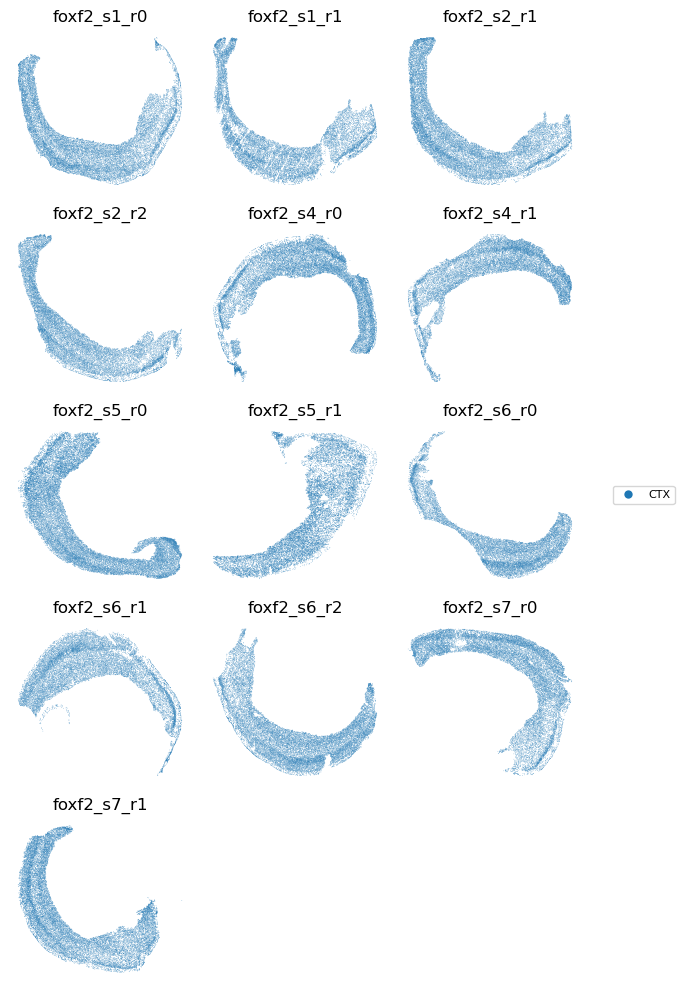

In [19]:
# brain region subsetting (optional)
adata, chosen_brain_regions = subset_by_brain_region(
    adata, method_path, args.brain_region_subset, logger
)
if chosen_brain_regions:
    from cellseg_benchmark.adata_utils import plot_spatial_multiplot

    plot_spatial_multiplot(adata, "brain_region", size=0.2, figsize_per_ax=2)

In [20]:
adata = prepare_adata_for_rpy2(adata, key=args.subset_key)

In [21]:
del adata.varm
adata.obsm = {"spatial": adata.obsm["spatial"]}
del adata.obsp
adata.uns["pca"]["params"].pop("mask_var", None)

In [22]:
adata_dict = {}
unique_groups = adata.obs[args.subset_key].unique().tolist()
for key in unique_groups:
    tmp = adata[adata.obs[args.subset_key] == key].copy()
    adata_dict[key] = tmp
adata_dict["all"] = adata.copy()

In [23]:
adata_dict.keys()

dict_keys(['Neurons_Glut', 'Oligodendrocytes', 'OPCs', 'Astrocytes', 'Neurons_Dopa', 'ECs', 'Microglia', 'Neurons_Other', 'Pericytes', 'Neurons_Gaba', 'BAMs', 'SMCs', 'VLMCs', 'Undefined', 'Neurons_Granule_Immature', 'Immune_Other', 'Ependymal', 'Choroid_Plexus', 'all'])

In [24]:
del adata

In [25]:
# loop over cell types

In [26]:
# R setup
conv = ro.default_converter + ro.pandas2ri.converter + anndata2ri.converter
r_script = Path(sys.path[1]) / "cellseg_benchmark" / "dea_utils.r"
ro.r["source"](str(r_script))
nebula_run = ro.globalenv["nebula_run"]

In [27]:
# Restore R prints and messages to appear in Jupyter output again
# import importlib
# import rpy2.rinterface_lib.callbacks as rcb
# _keep_warn, _keep_error = rcb.consolewrite_warn, rcb.consolewrite_error
# rcb = importlib.reload(rcb)
# rcb.consolewrite_warn, rcb.consolewrite_error = _keep_warn, _keep_error

In [37]:
max_cells_r = (
    int(args.max_cells_per_condition)
    if args.max_cells_per_condition is not None
    else ro.NULL
)

In [38]:
all_degs = {}
with localconverter(conv):
    for group_i, adata_tmp in adata_dict.items():
        logger.info(f"---> Processing {group_i}...")
        levels = (
            adata_tmp.obs[args.condition_key].dropna().astype(str).unique().tolist()
        )
        if args.ref not in levels or len(levels) < 2:
            logger.info(f"    Skip {group_i}: ref missing or <2 conditions ({levels}).")
            continue
        tests = [
            g for g in (args.test_groups or levels) if g in levels and g != args.ref
        ]
        if not tests:
            logger.info(f"    Skip {group_i}: no tests vs ref ({levels}).")
            continue

        res_r = nebula_run(
            adata=adata_tmp,
            group_i=group_i,
            test_groups=ro.vectors.StrVector(tests),
            ref_group=args.ref,
            condition_col=args.condition_key,
            sample_col=args.sample_key,
            batch_col=(args.batch_key if args.batch_key else ro.NULL),
            max_cells_per_condition=max_cells_r,
        )
        if res_r is ro.NULL:
            logger.info(f"    Skip {group_i}: NEBULA failed/skipped in R.")
            continue
        all_degs[group_i] = ro.conversion.rpy2py(res_r)

2026-02-05 14:38:34,750 [INFO]: ---> Processing Neurons_Glut...
2026-02-05 14:44:35,584 [INFO]: ---> Processing Oligodendrocytes...
2026-02-05 14:53:17,547 [INFO]: ---> Processing OPCs...
2026-02-05 14:55:57,541 [INFO]: ---> Processing Astrocytes...
2026-02-05 14:59:06,864 [INFO]: ---> Processing Neurons_Dopa...
2026-02-05 15:02:13,690 [INFO]: ---> Processing ECs...
2026-02-05 15:05:49,242 [INFO]: ---> Processing Microglia...
2026-02-05 15:08:45,794 [INFO]: ---> Processing Neurons_Other...
2026-02-05 15:11:07,136 [INFO]: ---> Processing Pericytes...
2026-02-05 15:13:04,855 [INFO]: ---> Processing Neurons_Gaba...
2026-02-05 15:14:37,932 [INFO]: ---> Processing BAMs...
2026-02-05 15:15:49,310 [INFO]: ---> Processing SMCs...
2026-02-05 15:17:01,365 [INFO]: ---> Processing VLMCs...
2026-02-05 15:18:28,727 [INFO]: ---> Processing Undefined...
2026-02-05 15:20:09,752 [INFO]: ---> Processing Neurons_Granule_Immature...
2026-02-05 15:20:09,973 [INFO]: R: Skip: design not full rank with batch (

RRuntimeError: Error: Future (‘doFuture-1’) of class ClusterFuture interrupted, while running on ‘localhost’ (pid 1560516)


In [46]:
logger.info("Format output table...")
collapsed_df = pd.concat(
    [pd.DataFrame(v).assign(subset=k) for k, v in all_degs.items()], ignore_index=True
).drop(columns=["result_id", "subset_group"], errors="ignore")

2026-02-05 15:46:29,157 [INFO]: Format output table...


In [48]:
collapsed_df.head()

,gene,test_group,log2FC,FC,SE,PValue,FDR,method,design,subset,test,ref
0,Foxf2,GLKO,2.570204,5.938935,0.048888,0.000000e+00,0.000000e+00,NEBULA,~ genotype + slide + (1 | sample),Neurons_Glut,GLKOvsWT,WT
1,Pdgfrb,PCKO,1.503277,2.834860,0.131496,2.891082e-30,1.321224e-27,NEBULA,~ genotype + slide + (1 | sample),Neurons_Glut,PCKOvsWT,WT
2,Pdgfra,PCKO,0.434210,1.351171,0.070907,9.145814e-10,2.089819e-07,NEBULA,~ genotype + slide + (1 | sample),Neurons_Glut,PCKOvsWT,WT
3,Reln,PCKO,0.345188,1.270316,0.059325,5.935674e-09,9.042010e-07,NEBULA,~ genotype + slide + (1 | sample),Neurons_Glut,PCKOvsWT,WT
4,Reln,GLKO,0.275149,1.210119,0.051834,1.106679e-07,2.066767e-05,NEBULA,~ genotype + slide + (1 | sample),Neurons_Glut,GLKOvsWT,WT


In [49]:
from cellseg_benchmark.dea_utils import (
    add_ensembl_id,
    add_group_sample_counts,
    safe_sheet,
)

In [51]:
# Add sample/group counts
collapsed_df = add_group_sample_counts(
    collapsed_df,
    adata_dict,
    condition_key=args.condition_key,
    sample_key=args.sample_key,
    ref=args.ref,
    test_groups=args.test_groups,
    subset_group="subset",
)

if args.brain_region_subset:
    collapsed_df["brain_region_subset"] = args.brain_region_subset.strip()

collapsed_df = collapsed_df.set_index("gene")
collapsed_df.insert(collapsed_df.columns.get_loc("FC"), "gene", collapsed_df.index)

order = [
    "subset",
    *(["brain_region_subset"] if "brain_region_subset" in collapsed_df.columns else []),
    "gene",
    "FC",
    "log2FC",
    "PValue",
    "FDR",
    "wald",
    "method",
    "design",
    "test_group",
    "ref",
    "test",
]
cols = [c for c in order if c in collapsed_df.columns] + [
    c for c in collapsed_df.columns if c not in order
]
collapsed_df = collapsed_df.loc[:, cols]

logger.info("Add ensembl gene ids...")
collapsed_df = add_ensembl_id(collapsed_df, logger=logger)

2026-02-05 15:47:16,166 [INFO]: Add ensembl gene ids...
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
3 input query terms found no hit:	['H2afj', 'Pifo', 'Ctps']
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
2026-02-05 15:47:19,852 [INFO]: 496 unique symbols -> 496 mapped (100.0%)
2026-02-05 15:47:19,853 [INFO]: Renamed aliases: H2afj->H2aj, Pifo->Cimap3, Ctps->Ctps1


In [52]:
def mixed_format(x):
    return f"{x:.2e}" if abs(x) < 1e-4 else f"{x:.2f}"


pd.options.display.float_format = mixed_format

In [53]:
collapsed_df

,subset,brain_region_subset,gene,FC,log2FC,PValue,FDR,method,design,test_group,ref,test,SE,ensembl_id
gene,,,,,,,,,,,,,,
Foxf2,Neurons_Glut,cortex,Foxf2,5.94,2.57,0.00e+00,0.00e+00,NEBULA,~ genotype + slide + (1 | sample),GLKO,WT,GLKOvsWT,0.05,ENSMUSG00000038402
Pdgfrb,Neurons_Glut,cortex,Pdgfrb,2.83,1.50,2.89e-30,1.32e-27,NEBULA,~ genotype + slide + (1 | sample),PCKO,WT,PCKOvsWT,0.13,ENSMUSG00000024620
Pdgfra,Neurons_Glut,cortex,Pdgfra,1.35,0.43,9.15e-10,2.09e-07,NEBULA,~ genotype + slide + (1 | sample),PCKO,WT,PCKOvsWT,0.07,ENSMUSG00000029231
Reln,Neurons_Glut,cortex,Reln,1.27,0.35,5.94e-09,9.04e-07,NEBULA,~ genotype + slide + (1 | sample),PCKO,WT,PCKOvsWT,0.06,ENSMUSG00000042453
Reln,Neurons_Glut,cortex,Reln,1.21,0.28,1.11e-07,2.07e-05,NEBULA,~ genotype + slide + (1 | sample),GLKO,WT,GLKOvsWT,0.05,ENSMUSG00000042453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Itgb2l,Undefined,cortex,Itgb2l,0.99,-0.02,0.99,0.99,NEBULA,~ genotype + slide + (1 | sample),PCKO,WT,PCKOvsWT,1.05,ENSMUSG00000000157
Cldn5,Undefined,cortex,Cldn5,1.00,-0.01,0.99,0.99,NEBULA,~ genotype + slide + (1 | sample),ECKO,WT,ECKOvsWT,0.53,ENSMUSG00000041378
Ptprd,Undefined,cortex,Ptprd,1.00,0.01,0.99,1.00,NEBULA,~ genotype + slide + (1 | sample),PCKO,WT,PCKOvsWT,0.79,ENSMUSG00000028399


In [54]:
logger.info("Export table(s)...")
subset_key_clean = re.sub(r"[_-]", "", args.subset_key)
assert collapsed_df["method"].nunique() == 1, (
    f"Expected one unique method in output table, found {collapsed_df['method'].unique().tolist()}"
)
method_name = collapsed_df["method"].unique()[0]
br_tag = (
    f"_Subset-{args.brain_region_subset.strip()}" if args.brain_region_subset else ""
)
name = f"{args.cohort}-{args.condition_key}-by-{subset_key_clean}_{method_name}"
name += br_tag

2026-02-05 15:47:41,072 [INFO]: Export table(s)...


In [55]:
name

'foxf2-genotype-by-celltype_NEBULA_Subset-cortex'

In [56]:
for (method, test), df_mt in collapsed_df.groupby(["method", "test"]):
    df_mt = df_mt.loc[:, df_mt.notna().any()]  # drop all-NaN cols
    safe_test = re.sub(r"[^\w.-]+", "_", str(test))  # filename-safe
    xlsx = output_dir / f"{name}_{safe_test}.xlsx"
    if xlsx.exists() and not args.overwrite:
        logger.info(f"  Exists, skip: {xlsx}")
        continue
    used = set()
    with pd.ExcelWriter(xlsx, engine="xlsxwriter") as writer:
        for gid, g in df_mt.groupby("subset", sort=True):
            g.sort_values("PValue").to_excel(
                writer, sheet_name=safe_sheet(gid, used), index=False
            )
    logger.info(f"  Wrote: {xlsx}")

logger.info("Done.")

2026-02-05 15:47:45,668 [INFO]:   Wrote: /dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/foxf2/Cellpose_1_nuclei_model/dea/foxf2-genotype-by-celltype_NEBULA_Subset-cortex_ECKOvsWT.xlsx
2026-02-05 15:47:46,459 [INFO]:   Wrote: /dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/foxf2/Cellpose_1_nuclei_model/dea/foxf2-genotype-by-celltype_NEBULA_Subset-cortex_GLKOvsWT.xlsx
2026-02-05 15:47:47,420 [INFO]:   Wrote: /dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/foxf2/Cellpose_1_nuclei_model/dea/foxf2-genotype-by-celltype_NEBULA_Subset-cortex_PCKOvsWT.xlsx
2026-02-05 15:47:47,422 [INFO]: Done.
